# Toronto Island Ferry — Ticket Count Visualizations
**Assignment 3 | Data Visualization**

Dataset: [Toronto Island Ferry Ticket Counts](https://open.toronto.ca/dataset/toronto-island-ferry-ticket-counts/)

| # | Visualization | Tool |
|---|---------------|------|
| 1 | Time-series line chart — Sales vs Redemptions (June 2026) | **Python** (matplotlib) |
| 2 | Hourly average bar chart — busiest times of day | **Excel / Google Sheets** |

> Viz 2 data is exported as `hourly_avg_for_excel.csv` — open it in Excel and follow the instructions below.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Load & parse
df = pd.read_csv('Toronto Island Ferry Ticket Counts.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

df['Date'] = df['Timestamp'].dt.date
df['Hour'] = df['Timestamp'].dt.hour

# Filter to June 2026 for focused visualizations
df_june = df[df['Timestamp'].dt.strftime('%Y-%m') == '2026-06'].copy()

print(f"Total rows: {len(df):,}")
print(f"June 2026 rows: {len(df_june):,}")
print(f"June 2026 date range: {df_june['Timestamp'].min()} → {df_june['Timestamp'].max()}")
df_june.head()

Total rows: 273,417
June 2026 rows: 963
June 2026 date range: 2026-06-01 00:00:00 → 2026-06-12 18:30:00


,_id,Timestamp,Redemption Count,Sales Count,Date,Hour
272454,963,2026-06-01 00:00:00,0,3,2026-06-01,0
272455,962,2026-06-01 00:30:00,0,7,2026-06-01,0
272456,961,2026-06-01 01:00:00,0,1,2026-06-01,1
272457,960,2026-06-01 01:15:00,0,6,2026-06-01,1
272458,959,2026-06-01 02:45:00,0,3,2026-06-01,2


## Visualization 1 (Python) — Time-series: Sales vs Redemptions, June 2026

**Tool:** Python (matplotlib)  
**Audience:** Transit planners and city staff monitoring real-time ferry demand  
**Message:** Shows the daily rhythm of ticket sales vs actual boardings over 12 days in June 2026, and highlights overnight advance-purchase behaviour (sales without any redemptions)

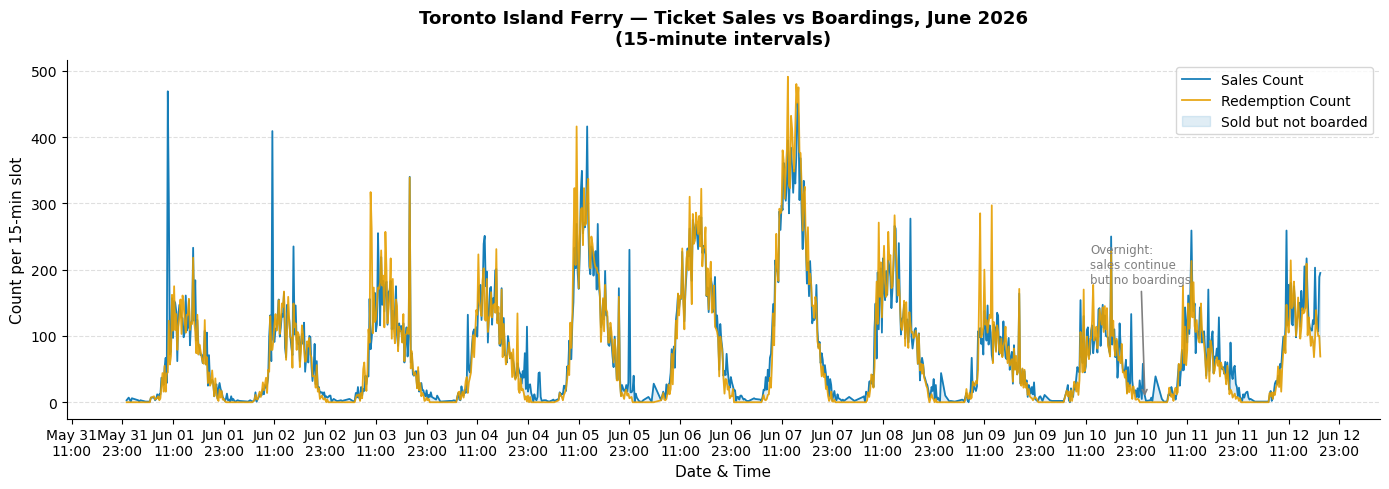

Saved: viz1_timeseries.png


In [2]:
COLOR_SALES = '#0072B2'        # blue  (colorblind-safe)
COLOR_REDEMPTION = '#E69F00'   # amber

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_june['Timestamp'], df_june['Sales Count'],
        color=COLOR_SALES, linewidth=1.3, label='Sales Count', alpha=0.9)
ax.plot(df_june['Timestamp'], df_june['Redemption Count'],
        color=COLOR_REDEMPTION, linewidth=1.3, label='Redemption Count', alpha=0.9)

# Shade gap: tickets sold but not yet boarded
ax.fill_between(
    df_june['Timestamp'],
    df_june['Redemption Count'], df_june['Sales Count'],
    where=df_june['Sales Count'] >= df_june['Redemption Count'],
    alpha=0.12, color=COLOR_SALES, label='Sold but not boarded'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.set_xlabel('Date & Time', fontsize=11)
ax.set_ylabel('Count per 15-min slot', fontsize=11)
ax.set_title(
    'Toronto Island Ferry — Ticket Sales vs Boardings, June 2026\n'
    '(15-minute intervals)',
    fontsize=13, fontweight='bold', pad=12
)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

# Annotate overnight sales-only window
midnight = pd.Timestamp('2026-06-11 01:00')
ax.annotate(
    'Overnight:\nsales continue\nbut no boardings',
    xy=(midnight, 5),
    xytext=(pd.Timestamp('2026-06-10 12:00'), 180),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
    fontsize=8.5, color='gray'
)

plt.tight_layout()
plt.savefig('viz1_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz1_timeseries.png')

## Visualization 2 (Excel / Google Sheets) — Hourly Average Bar Chart

**Tool:** Excel or Google Sheets  
**Audience:** General public deciding what time to visit Toronto Island  
**Message:** The ferry is consistently busiest between 10:00 and 15:00 every day

### Steps to create in Excel:
1. Run the cell below — it exports `hourly_avg_for_excel.csv`
2. Open Excel → **File → Open** → select `hourly_avg_for_excel.csv`
3. Select all data (Ctrl+A) → **Insert → Clustered Bar Chart** (or Column Chart)
4. Add chart title: *"Toronto Island Ferry — Average Boardings by Hour of Day"*
5. Label axes: X = "Hour of Day", Y = "Average Count (per 15-min slot)"
6. Change bar colours: Sales = blue (`#0072B2`), Redemptions = orange (`#E69F00`)
7. Export as PNG: **File → Save a Copy → PNG**

### Steps to create in Google Sheets:
1. Go to [sheets.google.com](https://sheets.google.com) → **File → Import** → upload `hourly_avg_for_excel.csv`
2. Select all data → **Insert → Chart** → Chart type: **Bar chart** or **Column chart**
3. Customise title and colours in "Customize" tab

In [3]:
# Export hourly averages for the Excel visualization
hourly_avg = (
    df.groupby('Hour')[['Sales Count', 'Redemption Count']]
    .mean()
    .round(1)
    .reset_index()
    .rename(columns={'Hour': 'Hour of Day',
                     'Sales Count': 'Avg Sales per 15-min',
                     'Redemption Count': 'Avg Boardings per 15-min'})
)
hourly_avg['Hour of Day'] = hourly_avg['Hour of Day'].apply(lambda h: f'{h:02d}:00')

hourly_avg.to_csv('hourly_avg_for_excel.csv', index=False)
print('Saved: hourly_avg_for_excel.csv')
print()
print(hourly_avg.to_string(index=False))

Saved: hourly_avg_for_excel.csv

Hour of Day  Avg Sales per 15-min  Avg Boardings per 15-min
      00:00                  10.6                       0.1
      01:00                   6.5                       0.6
      02:00                   4.5                       1.4
      03:00                   4.3                       2.1
      04:00                   3.1                       1.9
      05:00                   3.4                       1.3
      06:00                   8.8                      10.2
      07:00                  10.4                       8.2
      08:00                  23.9                      17.5
      09:00                  51.2                      45.7
      10:00                  73.1                      79.0
      11:00                  90.9                      96.4
      12:00                  92.8                      98.4
      13:00                  91.0                      95.4
      14:00                  89.9                      94.6
      1

---
## (Appendix) Optional Python Heatmap — Boarding Density by Hour & Date (June 2026)

This is supplementary code included as part of the Python appendix. It is NOT one of the two main submission visualizations.

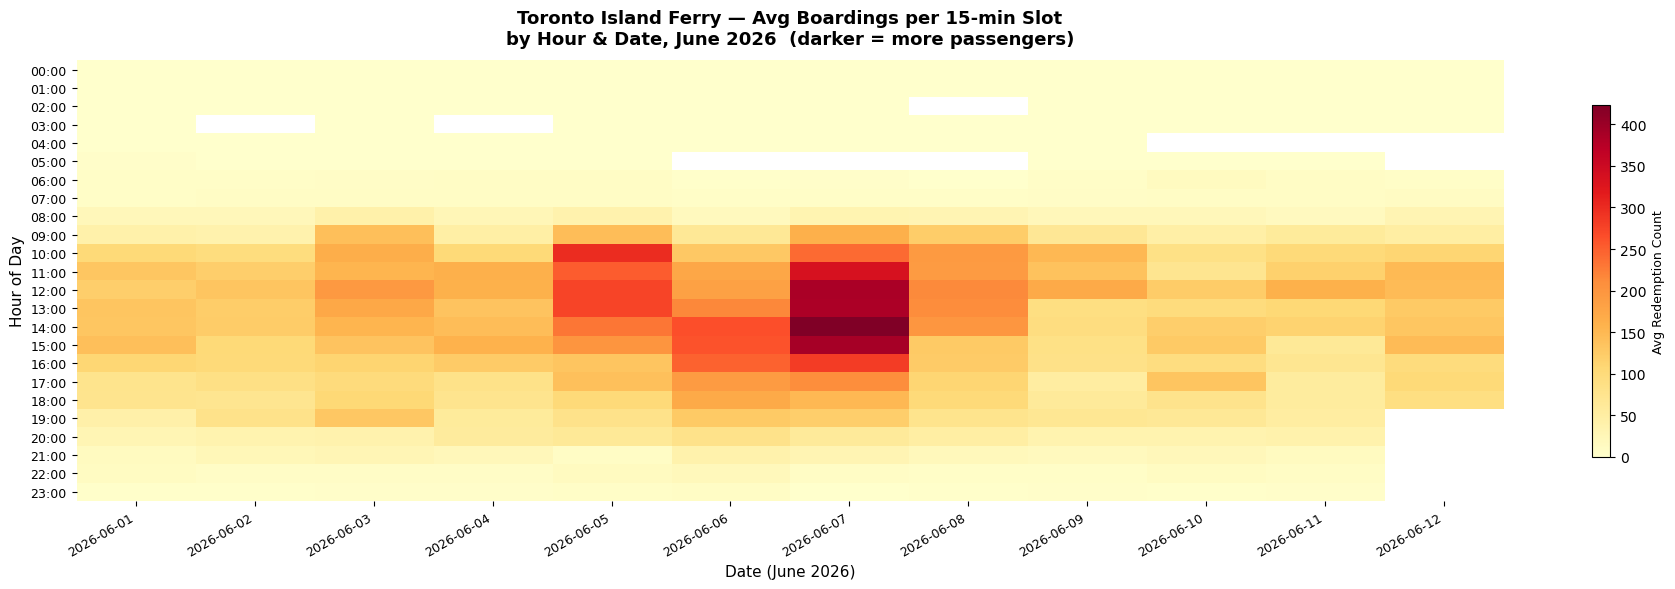

Saved: viz2_heatmap.png


In [4]:
# Heatmap filtered to June 2026 only (keeps file size small)
pivot = (
    df_june.groupby(['Date', 'Hour'])['Redemption Count']
    .mean()
    .reset_index()
    .pivot(index='Hour', columns='Date', values='Redemption Count')
)

n_dates = pivot.shape[1]
fig, ax = plt.subplots(figsize=(n_dates * 1.4 + 2, 6))

im = ax.imshow(
    pivot.values,
    aspect='auto',
    cmap='YlOrRd',
    interpolation='nearest',
    vmin=0
)

ax.set_xticks(range(n_dates))
ax.set_xticklabels([str(d) for d in pivot.columns], rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{h:02d}:00' for h in pivot.index], fontsize=9)
ax.set_xlabel('Date (June 2026)', fontsize=11)
ax.set_ylabel('Hour of Day', fontsize=11)
ax.set_title(
    'Toronto Island Ferry — Avg Boardings per 15-min Slot\n'
    'by Hour & Date, June 2026  (darker = more passengers)',
    fontsize=13, fontweight='bold', pad=12
)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Avg Redemption Count', fontsize=9)
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

plt.tight_layout()
plt.savefig('viz2_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved: viz2_heatmap.png')